# Water Segmentation from 12-Channel Multispectral/DEM Data (U-Net, PyTorch)

Dataset: 128x128x12 harmonized Sentinel-2/Landsat patches + auxiliary layers, with binary water masks.

**Band order (as given):**
`[Coastal aerosol, Blue, Green, Red, NIR, SWIR1, SWIR2, QA Band, Merit DEM, Copernicus DEM, ESA WorldCover, Water occurrence probability]`

This notebook covers: dataset exploration, per-band + RGB visualization, band research, label
distribution, dataset-wide per-channel normalization, water-index feature engineering, a
from-scratch PyTorch U-Net (baseline 12-channel vs. an enhanced version), and IoU/Precision/
Recall/F1 evaluation.


In [23]:
import os, glob, json, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected -- on Kaggle: Notebook Settings (right sidebar) > Accelerator > GPU T4 x2 (or P100).")


PyTorch version: 2.10.0+cu128
Device: cuda
GPU: Tesla T4


## 1. Get the Dataset

On Kaggle, the simplest and most reliable path is to upload the `data` folder (containing `images/` and `labels/`) as a **Kaggle Dataset**, then attach it via **+ Add Input** (right sidebar) -- no Drive download/quota concerns at all, since the files are already hosted on Kaggle.

**If you haven't uploaded it yet:** go to kaggle.com/datasets -> New Dataset -> upload the `data` folder (or a zip of it, Kaggle extracts zips automatically) -> once created, click **+ Add Input** in this notebook and select it.

The cell below auto-detects wherever `images/` and `labels/` end up under `/kaggle/input` (the exact subpath depends on your dataset's name and whether you zipped it), so you shouldn't need to hardcode a path.


In [24]:
import glob

# Auto-detect the dataset folder under /kaggle/input: looks for a directory that has both
# an 'images' and a 'labels' subfolder, wherever Kaggle placed your attached dataset.
candidates = [
    os.path.dirname(p) for p in glob.glob('/kaggle/input/**/images', recursive=True)
    if os.path.isdir(os.path.join(os.path.dirname(p), 'labels'))
]
assert candidates, (
    "No folder with both images/ and labels/ found under /kaggle/input -- make sure your "
    "dataset is attached via '+ Add Input' in the right sidebar, and that it contains a "
    "data/images/ and data/labels/ structure (possibly nested if you uploaded a zip)."
)
LOCAL_DATA_PATH = candidates[0]

IMAGES_DIR = os.path.join(LOCAL_DATA_PATH, 'images')
LABELS_DIR = os.path.join(LOCAL_DATA_PATH, 'labels')
assert os.path.exists(IMAGES_DIR), f"images/ not found at {IMAGES_DIR}"
assert os.path.exists(LABELS_DIR), f"labels/ not found at {LABELS_DIR}"
print(f"Images dir: {IMAGES_DIR}")
print(f"Labels dir: {LABELS_DIR}")

# All outputs (checkpoints, plots, final models) go to /kaggle/working -- Kaggle's persistent
# output directory, saved with the notebook version and downloadable from the "Output" tab.
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)


Images dir: /kaggle/input/datasets/amr33kassab/water-data/data/images
Labels dir: /kaggle/input/datasets/amr33kassab/water-data/data/labels


In [25]:
import os

print("Contents of /kaggle/input:")
for root, dirs, files in os.walk('/kaggle/input'):
    depth = root.count(os.sep) - '/kaggle/input'.count(os.sep)
    if depth > 3:
        dirs[:] = []  # don't descend further, just show the first few levels
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root) or root}/")
    for f in files[:5]:
        print(f"{indent}  {f}")
    if len(files) > 5:
        print(f"{indent}  ... ({len(files)} files total)")

Contents of /kaggle/input:
input/
  datasets/
    amr33kassab/
      water-data/


In [26]:
!pip install -q tifffile
import tifffile
from PIL import Image


## 2. Dataset Structure Exploration

In [27]:
image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, '*.tif')))
label_files = sorted(glob.glob(os.path.join(LABELS_DIR, '*.png')))

print(f"Number of image files: {len(image_files)}")
print(f"Number of label files: {len(label_files)}")

# Verify 1:1 correspondence by filename stem
img_stems = {os.path.splitext(os.path.basename(f))[0] for f in image_files}
lbl_stems = {os.path.splitext(os.path.basename(f))[0] for f in label_files}
print(f"Images without a matching label: {len(img_stems - lbl_stems)}")
print(f"Labels without a matching image: {len(lbl_stems - img_stems)}")

matched_stems = sorted(img_stems & lbl_stems)
print(f"Matched pairs: {len(matched_stems)}")

BAND_NAMES = [
    'Coastal aerosol', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2',
    'QA Band', 'Merit DEM', 'Copernicus DEM', 'ESA WorldCover', 'Water occurrence probability'
]
assert len(BAND_NAMES) == 12

# Inspect one sample
sample_img = tifffile.imread(image_files[0])
sample_lbl = np.array(Image.open(label_files[0]))

print(f"\nRaw image array shape: {sample_img.shape}, dtype: {sample_img.dtype}")
print(f"Raw label array shape: {sample_lbl.shape}, dtype: {sample_lbl.dtype}")
print(f"Label unique values: {np.unique(sample_lbl)}")

# Auto-detect channel-first vs channel-last layout
def to_chw(arr):
    """Standardize a loaded (H,W,12) or (12,H,W) array to channel-first (12,H,W) float32."""
    arr = np.asarray(arr)
    if arr.shape[0] == 12:
        pass  # already (12, H, W)
    elif arr.shape[-1] == 12:
        arr = np.transpose(arr, (2, 0, 1))
    else:
        raise ValueError(f"Can't find a 12-channel axis in shape {arr.shape}")
    return arr.astype(np.float32)

chw = to_chw(sample_img)
print(f"\nStandardized image shape (C,H,W): {chw.shape}")
assert chw.shape == (12, 128, 128), f"Expected (12,128,128), got {chw.shape}"

for i, name in enumerate(BAND_NAMES):
    b = chw[i]
    print(f"  Band {i:2d} {name:<28s}: min={b.min():.2f}  max={b.max():.2f}  mean={b.mean():.2f}")


Number of image files: 306
Number of label files: 456
Images without a matching label: 0
Labels without a matching image: 150
Matched pairs: 306

Raw image array shape: (128, 128, 12), dtype: int16
Raw label array shape: (128, 128), dtype: uint8
Label unique values: [0 1]

Standardized image shape (C,H,W): (12, 128, 128)
  Band  0 Coastal aerosol             : min=14.00  max=532.00  mean=174.06
  Band  1 Blue                        : min=-28.00  max=846.00  mean=166.07
  Band  2 Green                       : min=-2.00  max=1099.00  mean=326.94
  Band  3 Red                         : min=2.00  max=1297.00  mean=325.77
  Band  4 NIR                         : min=46.00  max=4975.00  mean=1945.23
  Band  5 SWIR1                       : min=30.00  max=3786.00  mean=1298.18
  Band  6 SWIR2                       : min=16.00  max=3004.00  mean=678.84
  Band  7 QA Band                     : min=64.00  max=160.00  mean=66.34
  Band  8 Merit DEM                   : min=130.00  max=355.00  mean=24

## 3. Visualize All 12 Bands + RGB Composite

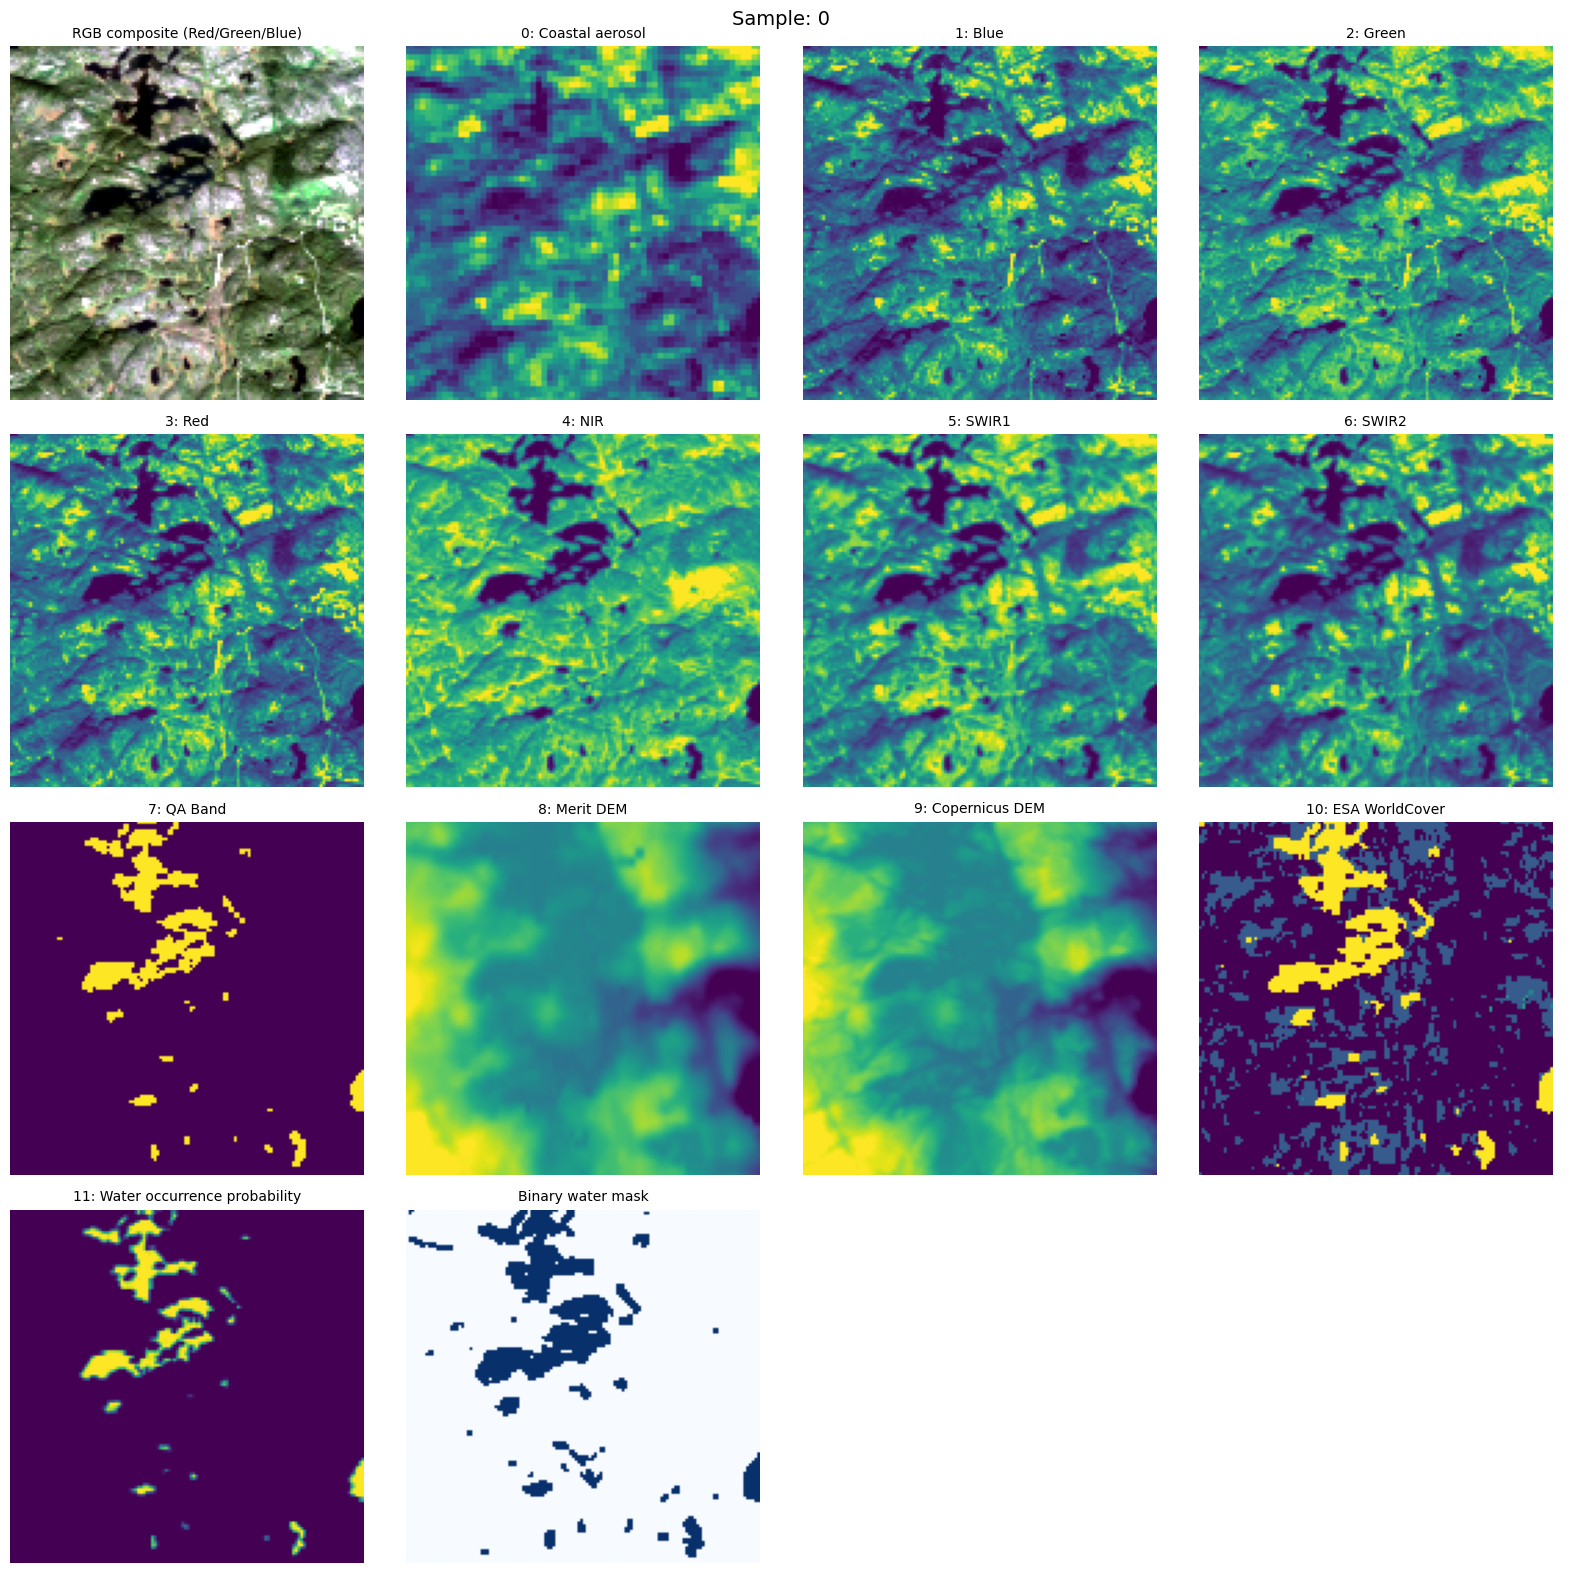

In [28]:
def load_sample(stem):
    img = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
    lbl = np.array(Image.open(os.path.join(LABELS_DIR, stem + '.png')))
    lbl = (lbl > 0).astype(np.uint8)  # binarize just in case it's 0/255
    return img, lbl

def stretch(band, p_lo=2, p_hi=98):
    """Simple percentile contrast stretch to [0,1] for display only."""
    lo, hi = np.percentile(band, [p_lo, p_hi])
    if hi <= lo:
        return np.zeros_like(band)
    return np.clip((band - lo) / (hi - lo), 0, 1)

def plot_all_bands_and_rgb(stem):
    img, lbl = load_sample(stem)

    fig, axes = plt.subplots(4, 4, figsize=(16, 16))
    axes = axes.ravel()

    # True-color RGB composite: Red=band3, Green=band2, Blue=band1
    rgb = np.stack([stretch(img[3]), stretch(img[2]), stretch(img[1])], axis=-1)
    axes[0].imshow(rgb)
    axes[0].set_title('RGB composite (Red/Green/Blue)', fontsize=10)
    axes[0].axis('off')

    for i, name in enumerate(BAND_NAMES):
        ax = axes[i + 1]
        ax.imshow(stretch(img[i]), cmap='viridis')
        ax.set_title(f'{i}: {name}', fontsize=10)
        ax.axis('off')

    axes[13].imshow(lbl, cmap='Blues')
    axes[13].set_title('Binary water mask', fontsize=10)
    axes[13].axis('off')

    for j in range(14, 16):
        axes[j].axis('off')

    fig.suptitle(f'Sample: {stem}', fontsize=14)
    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_bands.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_all_bands_and_rgb(matched_stems[0])


## 4. Band Research: What Each Channel Measures & How Water Affects It

*(Research task -- fill in/adjust with your own reading; this is a starting point.)*

| # | Band | Wavelength / Type | Water behavior |
|---|---|---|---|
| 0 | Coastal aerosol | ~443 nm | Mainly used for atmospheric correction (aerosol/haze); water reflectance here is low and noisy, limited standalone value for water detection. |
| 1 | Blue | ~490 nm | Water penetration is moderate; used in some turbidity/chlorophyll indices, but land and water aren't strongly separated here alone. |
| 2 | Green | ~560 nm | Water reflects slightly more than in Red/NIR, vegetation reflects strongly. Core input to the McFeeters NDWI (Green-NIR). |
| 3 | Red | ~665 nm | Water absorbs red light strongly (low reflectance); vegetation and bare soil reflect noticeably more. |
| 4 | NIR | ~842 nm | **Water absorbs NIR almost completely** -- the single most discriminative band between water and (highly NIR-reflective) vegetation/land. Basis of NDVI and NDWI. |
| 5 | SWIR1 | ~1610 nm | Water reflectance ~0. More robust than NIR for separating water from shadows/built-up areas. Basis of MNDWI (Green-SWIR1), generally outperforms NDWI in urban scenes. |
| 6 | SWIR2 | ~2200 nm | Also ~0 over water; sensitive to soil/vegetation moisture content, helps further disambiguate wet soil vs. open water. |
| 7 | QA Band | Bitmask (categorical) | Not reflectance -- flags cloud, cloud shadow, snow/ice, saturation. Shouldn't be treated as a continuous value; useful as a mask/filter or decoded into separate binary flags. |
| 8 | Merit DEM | Elevation (m) | Water bodies sit in local topographic minima / flat valley bottoms -- useful geographic context, not spectral signal. |
| 9 | Copernicus DEM | Elevation (m), different source | Same purpose as Merit DEM; cross-referencing two DEM products can reduce artifacts/voids present in a single source. |
| 10 | ESA WorldCover | Land-cover class code | **Already contains an explicit "permanent water bodies" class.** Using this raw is close to handing the model a pre-made water map for a large fraction of pixels -- strong signal, but worth flagging as a near-leakage feature (see note below). |
| 11 | Water occurrence probability | % of time historically classified as water | Typically a JRC Global Surface Water-style product. Extremely predictive for *permanent* water, but can mismatch newly-flooded or newly-dried areas -- also a near-leakage feature for this task. |

**Leakage note:** bands 10 and 11 are not raw sensor measurements of the current scene -- they're
*pre-computed water-related products*. A model that relies heavily on them will likely score very
well but isn't really learning multispectral water *segmentation* so much as reading an existing
map. Worth running an ablation (with vs. without bands 10/11) and discussing the gap in your
README -- this is very likely part of what your mentor means by not just using "the basic 12
channel" input naively.


## 5. Label Distribution

Total images: 306
Overall water-pixel fraction: 25.98%
Per-image water fraction -- mean: 25.98%, median: 16.45%
Images with ~0% water pixels: 54 (17.6%)
Images that are mostly water (>90%): 12


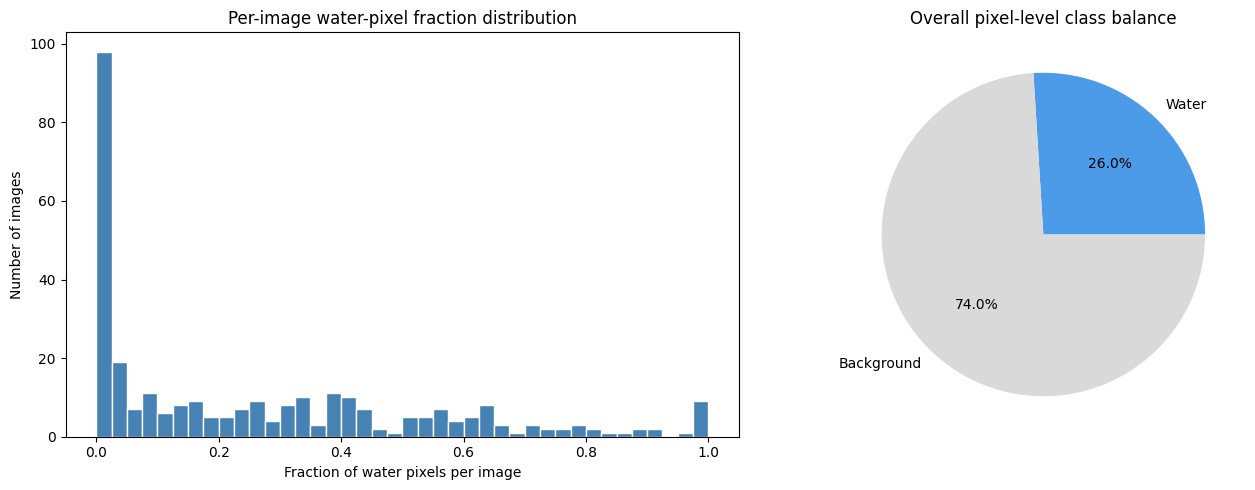

In [29]:
water_fractions = []
for stem in matched_stems:
    lbl = np.array(Image.open(os.path.join(LABELS_DIR, stem + '.png')))
    lbl = (lbl > 0).astype(np.uint8)
    water_fractions.append(lbl.mean())

water_fractions = np.array(water_fractions)
total_pixels = len(matched_stems) * 128 * 128
total_water_pixels = int((water_fractions * 128 * 128).sum())

print(f"Total images: {len(matched_stems)}")
print(f"Overall water-pixel fraction: {total_water_pixels/total_pixels*100:.2f}%")
print(f"Per-image water fraction -- mean: {water_fractions.mean()*100:.2f}%, "
      f"median: {np.median(water_fractions)*100:.2f}%")
print(f"Images with ~0% water pixels: {(water_fractions < 0.001).sum()} "
      f"({(water_fractions < 0.001).mean()*100:.1f}%)")
print(f"Images that are mostly water (>90%): {(water_fractions > 0.9).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(water_fractions, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Fraction of water pixels per image')
axes[0].set_ylabel('Number of images')
axes[0].set_title('Per-image water-pixel fraction distribution')

axes[1].pie([total_water_pixels, total_pixels - total_water_pixels],
            labels=['Water', 'Background'], autopct='%1.1f%%',
            colors=['#4C9BE8', '#D9D9D9'])
axes[1].set_title('Overall pixel-level class balance')
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


## 6. Research Notes

**Why 12 channels instead of RGB:**
RGB alone only captures what's visible to the human eye. Water's most distinctive physical
property -- near-total absorption in NIR and SWIR -- is completely invisible in RGB; a muddy
river and wet soil can look nearly identical in visible light but are very different in NIR/SWIR.
Multispectral input also lets the model (or a hand-built index) exploit *band ratios*, which are
far more robust to illumination/atmospheric differences between scenes than raw RGB brightness.
Adding DEM and land-cover layers further gives geographic/topographic context no optical sensor
can provide on its own (e.g. "this pixel sits in a valley bottom" is a strong prior regardless of
reflectance).

**Why U-Net suits pixel-level segmentation:**
The encoder progressively downsamples to build increasingly abstract, large-receptive-field
features (what's in the scene), while the decoder upsamples back to full resolution to recover
where each feature is. Skip connections carry fine-grained spatial detail (edges, exact
boundaries) directly from encoder to decoder at matching resolutions -- without them, the decoder
would have to reconstruct precise water-body boundaries purely from the heavily-downsampled
bottleneck, which loses exactly that detail. This is what makes U-Net well suited to *dense*,
pixel-accurate prediction tasks rather than just whole-image classification.


## 7. Train / Val / Test Split

Split first, **then** compute normalization statistics only from the training set -- computing
stats over the full dataset (including val/test) would leak information about the evaluation
data into preprocessing.


In [30]:
from sklearn.model_selection import train_test_split

# Stratify the split roughly by water content (binned) so train/val/test each get a similar
# mix of water-heavy, mixed, and near-empty tiles -- plain random split risks an unlucky split
# where e.g. most water-heavy tiles land in train only.
water_bins = np.digitize(water_fractions, bins=[0.001, 0.1, 0.3, 0.6])

train_stems, temp_stems, train_bins, temp_bins = train_test_split(
    matched_stems, water_bins, test_size=0.20, random_state=SEED, stratify=water_bins
)
val_stems, test_stems = train_test_split(
    temp_stems, test_size=0.50, random_state=SEED, stratify=temp_bins
)

print(f"Train: {len(train_stems)}  Val: {len(val_stems)}  Test: {len(test_stems)}")


Train: 244  Val: 31  Test: 31


## 8. Dataset-Wide, Per-Channel Normalization

**The common mistake:** normalizing each image independently (e.g. `(img - img.min()) / (img.max() - img.min())`
computed per-sample) makes the same real-world reflectance value map to different normalized
values in different images, depending on what else happens to be in that particular 128x128
patch. That's inconsistent and makes it harder for the network to learn a stable mapping.

**The correct approach:** compute **one set of statistics per channel, over the entire training
set**, then apply that same fixed per-channel transform to every image (train/val/test alike).


In [31]:
STATS_PATH = '/kaggle/working/channel_stats.json'

def compute_channel_stats(stems):
    n_channels = 12
    mins = np.full(n_channels, np.inf)
    maxs = np.full(n_channels, -np.inf)
    sums = np.zeros(n_channels)
    sums_sq = np.zeros(n_channels)
    pixel_count = 0

    for stem in stems:
        img = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
        mins = np.minimum(mins, img.min(axis=(1, 2)))
        maxs = np.maximum(maxs, img.max(axis=(1, 2)))
        sums += img.sum(axis=(1, 2))
        sums_sq += (img.astype(np.float64) ** 2).sum(axis=(1, 2))
        pixel_count += img.shape[1] * img.shape[2]

    means = sums / pixel_count
    stds = np.sqrt(sums_sq / pixel_count - means ** 2)
    stds = np.maximum(stds, 1e-6)  # avoid divide-by-zero on a constant channel
    return {'min': mins.tolist(), 'max': maxs.tolist(), 'mean': means.tolist(), 'std': stds.tolist()}

if not os.path.exists(STATS_PATH):
    print(f"Computing per-channel statistics over {len(train_stems)} training images...")
    t0 = time.time()
    stats = compute_channel_stats(train_stems)
    with open(STATS_PATH, 'w') as f:
        json.dump(stats, f, indent=2)
    print(f"Done in {time.time()-t0:.1f}s")
else:
    with open(STATS_PATH) as f:
        stats = json.load(f)
    print("Loaded existing channel stats.")

for i, name in enumerate(BAND_NAMES):
    print(f"  {i:2d} {name:<28s}: min={stats['min'][i]:9.2f}  max={stats['max'][i]:9.2f}  "
          f"mean={stats['mean'][i]:9.2f}  std={stats['std'][i]:9.2f}")

CH_MIN = np.array(stats['min'], dtype=np.float32).reshape(-1, 1, 1)
CH_MAX = np.array(stats['max'], dtype=np.float32).reshape(-1, 1, 1)

def normalize_channels(img):
    """Per-channel min-max scaling to [0,1], using TRAIN-set statistics only (fixed, not re-fit per image)."""
    rng = np.maximum(CH_MAX - CH_MIN, 1e-6)
    return np.clip((img - CH_MIN) / rng, 0, 1)


Computing per-channel statistics over 244 training images...
Done in 2.5s
   0 Coastal aerosol             : min= -1390.00  max=  6568.00  mean=   397.53  std=   283.37
   1 Blue                        : min= -1110.00  max=  9659.00  mean=   495.95  std=   339.99
   2 Green                       : min=  -633.00  max= 11368.00  mean=   820.99  std=   427.53
   3 Red                         : min=  -627.00  max= 12041.00  mean=   971.29  std=   588.88
   4 NIR                         : min=  -408.00  max= 15841.00  mean=  2059.09  std=  1045.53
   5 SWIR1                       : min=  -335.00  max= 15252.00  mean=  1939.80  std=  1177.91
   6 SWIR2                       : min=  -251.00  max= 14647.00  mean=  1336.61  std=   943.79
   7 QA Band                     : min=    64.00  max=   255.00  mean=   102.51  std=    48.93
   8 Merit DEM                   : min= -9999.00  max=  4245.00  mean=   142.16  std=  1447.44
   9 Copernicus DEM              : min=     8.00  max=  4287.00  mean= 

## 9. Feature Engineering: Water Indices

Going beyond the raw 12 bands, as your mentor asked. These are computed from the **raw**
(pre-normalization) reflectance bands, since the formulas assume physically meaningful reflectance
differences, then the resulting index layers are normalized the same dataset-wide way as the rest.

- **NDWI** (McFeeters) `= (Green - NIR) / (Green + NIR)` -- classic water index, water is strongly
  positive, vegetation strongly negative.
- **MNDWI** (Modified NDWI, Xu) `= (Green - SWIR1) / (Green + SWIR1)` -- generally more robust than
  NDWI in built-up/urban areas, since SWIR separates water from shadow/concrete better than NIR does.
- **NDVI** `= (NIR - Red) / (NIR + Red)` -- not a water index itself, but helps the model
  disambiguate vegetation (high NDVI) from water/bare soil, indirectly sharpening water boundaries.
- **ESA "is water class" flag** -- binarized from the raw WorldCover categorical band
  (class code 80 = permanent water bodies in the ESA WorldCover legend), as an explicit derived
  feature rather than feeding the raw class codes directly.


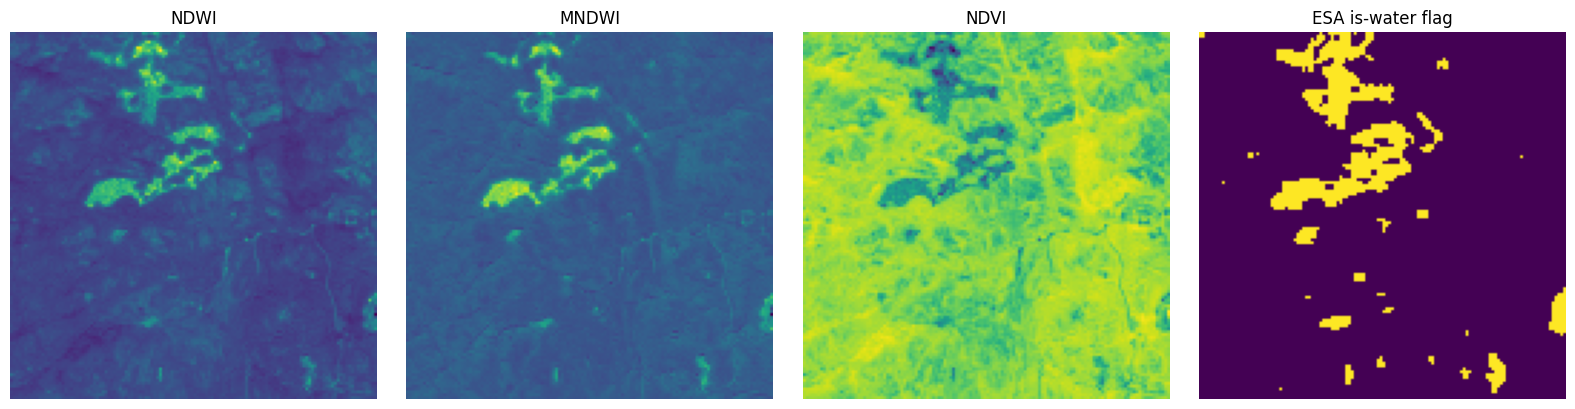

In [45]:
EPS = 1e-6

def compute_indices(raw_img):
    """raw_img: (12, H, W) float32, RAW (not yet normalized) reflectance/DEM values."""
    blue, green, red, nir, swir1 = raw_img[1], raw_img[2], raw_img[3], raw_img[4], raw_img[5]
    esa_worldcover = raw_img[10]

    ndwi  = np.clip((green - nir) / (green + nir + EPS), -1, 1)
    mndwi = np.clip((green - swir1) / (green + swir1 + EPS), -1, 1)
    ndvi  = np.clip((nir - red) / (nir + red + EPS), -1, 1)
    esa_is_water = (np.round(esa_worldcover) == 80).astype(np.float32)

    ndwi01  = (ndwi + 1) / 2
    mndwi01 = (mndwi + 1) / 2
    ndvi01  = (ndvi + 1) / 2

    return np.stack([ndwi01, mndwi01, ndvi01, esa_is_water], axis=0).astype(np.float32)

EXTRA_FEATURE_NAMES = ['NDWI', 'MNDWI', 'NDVI', 'ESA is-water flag']

# Quick visual sanity check on one sample
sample_raw = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, matched_stems[0] + '.tif')))
sample_extra = compute_indices(sample_raw)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, name in enumerate(EXTRA_FEATURE_NAMES):
    axes[i].imshow(sample_extra[i], cmap='viridis')
    axes[i].set_title(name)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/engineered_features.png', dpi=100, bbox_inches='tight')
plt.show()


## 10. PyTorch Dataset & DataLoaders

`USE_ENGINEERED_FEATURES` toggles between the plain 12-channel baseline and the enhanced
16-channel (12 raw + NDWI + MNDWI + NDVI + ESA-is-water) input -- used to train and compare both
models, per the assignment's requirement to go beyond the basic baseline.


In [46]:
class WaterSegDataset(Dataset):
    def __init__(self, stems, use_engineered_features=True, augment=False):
        self.stems = stems
        self.use_engineered_features = use_engineered_features
        self.augment = augment

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, idx):
        stem = self.stems[idx]
        raw_img = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
        mask = np.array(Image.open(os.path.join(LABELS_DIR, stem + '.png')))
        mask = (mask > 0).astype(np.float32)

        norm_img = normalize_channels(raw_img)  # (12, H, W) in [0,1], train-set stats

        if self.use_engineered_features:
            extra = compute_indices(raw_img)     # (4, H, W) in [0,1]
            img = np.concatenate([norm_img, extra], axis=0)  # (16, H, W)
        else:
            img = norm_img  # (12, H, W)

        if self.augment:
            if random.random() < 0.5:
                img = np.flip(img, axis=2).copy()
                mask = np.flip(mask, axis=1).copy()
            if random.random() < 0.5:
                img = np.flip(img, axis=1).copy()
                mask = np.flip(mask, axis=0).copy()
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k, axes=(1, 2)).copy()
                mask = np.rot90(mask, k, axes=(0, 1)).copy()

        return torch.from_numpy(img).float(), torch.from_numpy(mask).unsqueeze(0).float()


def make_loaders(use_engineered_features, batch_size=16):
    train_ds = WaterSegDataset(train_stems, use_engineered_features, augment=True)
    val_ds   = WaterSegDataset(val_stems,   use_engineered_features, augment=False)
    test_ds  = WaterSegDataset(test_stems,  use_engineered_features, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

# Sanity check
_tmp_loader, _, _ = make_loaders(use_engineered_features=True, batch_size=4)
xb, yb = next(iter(_tmp_loader))
print(f"Batch image shape: {tuple(xb.shape)}  (expect [B, 16, 128, 128])")
print(f"Batch mask shape:  {tuple(yb.shape)}  (expect [B, 1, 128, 128])")


Batch image shape: (4, 16, 128, 128)  (expect [B, 16, 128, 128])
Batch mask shape:  (4, 1, 128, 128)  (expect [B, 1, 128, 128])


## 11. U-Net From Scratch

A standard encoder-decoder with skip connections, parametrized by `in_channels` so the same class
builds both the 12-channel baseline and the 16-channel enhanced model.

`use_se` adds lightweight Squeeze-and-Excitation blocks (channel attention) to each encoder/decoder
stage -- a from-scratch architectural improvement over the plain baseline U-Net, independent of the
extra input channels, satisfying the "model optimization" half of going beyond baseline.


In [47]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: learns per-channel importance weights."""
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, max(channels // reduction, 4)),
            nn.ReLU(inplace=True),
            nn.Linear(max(channels // reduction, 4), channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1, 1)
        return x * w


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if use_se:
            layers.append(SEBlock(out_ch))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Down(nn.Module):
    def __init__(self, in_ch, out_ch, use_se=False):
        super().__init__()
        self.pool_conv = nn.Sequential(nn.MaxPool2d(2), DoubleConv(in_ch, out_ch, use_se))

    def forward(self, x):
        return self.pool_conv(x)


class Up(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, use_se=False):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch // 2 + skip_ch, out_ch, use_se)

    def forward(self, x, skip):
        x = self.upsample(x)
        # Pad if needed (in case of odd input sizes -- not expected at 128x128, but safe)
        diff_y = skip.size(2) - x.size(2)
        diff_x = skip.size(3) - x.size(3)
        x = F.pad(x, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, base_ch=32, use_se=False):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base_ch, use_se)
        self.down1 = Down(base_ch,     base_ch * 2, use_se)
        self.down2 = Down(base_ch * 2, base_ch * 4, use_se)
        self.down3 = Down(base_ch * 4, base_ch * 8, use_se)
        self.down4 = Down(base_ch * 8, base_ch * 16, use_se)

        self.up1 = Up(base_ch * 16, base_ch * 8, base_ch * 8, use_se)
        self.up2 = Up(base_ch * 8,  base_ch * 4, base_ch * 4, use_se)
        self.up3 = Up(base_ch * 4,  base_ch * 2, base_ch * 2, use_se)
        self.up4 = Up(base_ch * 2,  base_ch,     base_ch,     use_se)

        self.outc = nn.Conv2d(base_ch, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)  # raw logits, shape (B, 1, H, W)


# Quick shape check for both configurations
for ch, label in [(12, 'baseline (12ch)'), (16, 'enhanced (16ch)')]:
    m = UNet(in_channels=ch, use_se=(ch == 16))
    dummy = torch.randn(2, ch, 128, 128)
    out = m(dummy)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{label}: input {tuple(dummy.shape)} -> output {tuple(out.shape)}  ({n_params:,} params)")


baseline (12ch): input (2, 12, 128, 128) -> output (2, 1, 128, 128)  (7,765,633 params)
enhanced (16ch): input (2, 16, 128, 128) -> output (2, 1, 128, 128)  (7,877,497 params)


## 12. Loss Function & Metrics

Water pixels are a minority class overall (see Section 5), so plain BCE alone tends to let the
model lean toward predicting "background" everywhere and still score deceptively well on pixel
accuracy. **Dice loss** directly optimizes overlap (closely related to IoU/F1) and is far less
sensitive to class imbalance, so we combine it with BCE.


In [48]:
class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.smooth = smooth

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.reshape(probs.size(0), -1)
        targets_flat = targets.reshape(targets.size(0), -1)
        intersection = (probs_flat * targets_flat).sum(dim=1)
        dice = (2 * intersection + self.smooth) / (probs_flat.sum(dim=1) + targets_flat.sum(dim=1) + self.smooth)
        dice_loss = 1 - dice.mean()

        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


@torch.no_grad()
def compute_confusion(logits, targets, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    tn = ((1 - preds) * (1 - targets)).sum().item()
    return tp, fp, fn, tn


def metrics_from_confusion(tp, fp, fn, tn, eps=1e-7):
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)
    return {'precision': precision, 'recall': recall, 'f1': f1, 'iou': iou}


## 13. Training Loop

In [49]:
def train_model(model, train_loader, val_loader, model_name, epochs=30, lr=1e-3, patience=7):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    criterion = DiceBCELoss()

    ckpt_path = f'/kaggle/working/{model_name}_best.pt'
    best_val_f1 = -1
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'val_iou': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        tp = fp = fn = tn = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * xb.size(0)
                btp, bfp, bfn, btn = compute_confusion(logits, yb)
                tp += btp; fp += bfp; fn += bfn; tn += btn
        val_loss /= len(val_loader.dataset)
        val_metrics = metrics_from_confusion(tp, fp, fn, tn)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_metrics['f1'])
        history['val_iou'].append(val_metrics['iou'])

        improved = val_metrics['f1'] > best_val_f1
        if improved:
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), ckpt_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"[{model_name}] Epoch {epoch:3d}/{epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_F1={val_metrics['f1']:.4f} | val_IoU={val_metrics['iou']:.4f}"
              + ("  (best)" if improved else ""))

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no val_F1 improvement for {patience} epochs).")
            break

    model.load_state_dict(torch.load(ckpt_path))
    return model, history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='train_loss')
    axes[0].plot(history['val_loss'], label='val_loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_title(f'{title} -- Loss'); axes[0].legend()

    axes[1].plot(history['val_f1'], label='val_F1')
    axes[1].plot(history['val_iou'], label='val_IoU')
    axes[1].set_xlabel('Epoch'); axes[1].set_title(f'{title} -- Val F1 / IoU'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{title.replace(" ", "_")}_curves.png', dpi=100, bbox_inches='tight')
    plt.show()


## 14. Train Both Models

**Baseline:** plain 12-channel input, plain U-Net (no SE blocks) -- matches what the assignment
calls the default most people stop at.

**Enhanced:** 16-channel input (12 raw bands + NDWI + MNDWI + NDVI + ESA-is-water flag) and SE
attention blocks in the U-Net -- the "beyond baseline" version via feature engineering **and**
model optimization together, per your mentor's note.


[unet_baseline] Epoch   1/30 | train_loss=0.5650 | val_loss=0.5971 | val_F1=0.5587 | val_IoU=0.3877  (best)
[unet_baseline] Epoch   2/30 | train_loss=0.5000 | val_loss=0.5104 | val_F1=0.7655 | val_IoU=0.6200  (best)
[unet_baseline] Epoch   3/30 | train_loss=0.4783 | val_loss=0.4787 | val_F1=0.7680 | val_IoU=0.6234  (best)
[unet_baseline] Epoch   4/30 | train_loss=0.4580 | val_loss=0.4560 | val_F1=0.7565 | val_IoU=0.6084
[unet_baseline] Epoch   5/30 | train_loss=0.4386 | val_loss=0.4413 | val_F1=0.7827 | val_IoU=0.6429  (best)
[unet_baseline] Epoch   6/30 | train_loss=0.4361 | val_loss=0.4851 | val_F1=0.7382 | val_IoU=0.5850
[unet_baseline] Epoch   7/30 | train_loss=0.4235 | val_loss=0.4347 | val_F1=0.7756 | val_IoU=0.6335
[unet_baseline] Epoch   8/30 | train_loss=0.4181 | val_loss=0.4129 | val_F1=0.7756 | val_IoU=0.6335
[unet_baseline] Epoch   9/30 | train_loss=0.4148 | val_loss=0.4088 | val_F1=0.7732 | val_IoU=0.6303
[unet_baseline] Epoch  10/30 | train_loss=0.4086 | val_loss=0.4023 |

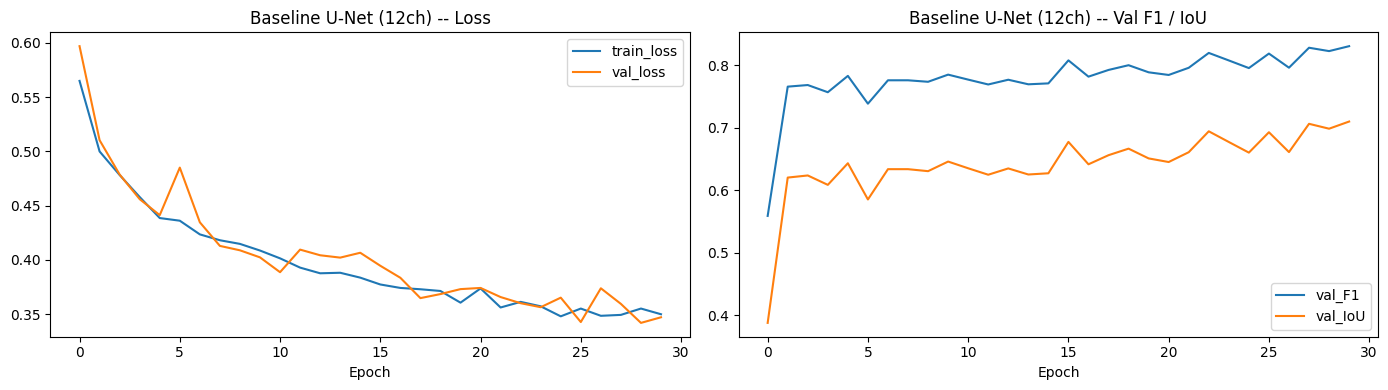

In [50]:
BATCH_SIZE = 16
EPOCHS = 30

# --- Baseline: 12 channels, plain U-Net ---
train_loader_base, val_loader_base, test_loader_base = make_loaders(use_engineered_features=False, batch_size=BATCH_SIZE)
baseline_model = UNet(in_channels=12, use_se=False, base_ch=32)
baseline_model, baseline_history = train_model(
    baseline_model, train_loader_base, val_loader_base, model_name='unet_baseline', epochs=EPOCHS
)
plot_history(baseline_history, 'Baseline U-Net (12ch)')


[unet_enhanced] Epoch   1/30 | train_loss=0.5892 | val_loss=0.6499 | val_F1=0.1619 | val_IoU=0.0881  (best)
[unet_enhanced] Epoch   2/30 | train_loss=0.5341 | val_loss=0.5737 | val_F1=0.6873 | val_IoU=0.5236  (best)
[unet_enhanced] Epoch   3/30 | train_loss=0.5125 | val_loss=0.5095 | val_F1=0.7774 | val_IoU=0.6359  (best)
[unet_enhanced] Epoch   4/30 | train_loss=0.4806 | val_loss=0.5214 | val_F1=0.7811 | val_IoU=0.6409  (best)
[unet_enhanced] Epoch   5/30 | train_loss=0.4659 | val_loss=0.4623 | val_F1=0.7744 | val_IoU=0.6319
[unet_enhanced] Epoch   6/30 | train_loss=0.4452 | val_loss=0.4094 | val_F1=0.7778 | val_IoU=0.6364
[unet_enhanced] Epoch   7/30 | train_loss=0.4251 | val_loss=0.4107 | val_F1=0.7854 | val_IoU=0.6466  (best)
[unet_enhanced] Epoch   8/30 | train_loss=0.4101 | val_loss=0.3877 | val_F1=0.7805 | val_IoU=0.6400
[unet_enhanced] Epoch   9/30 | train_loss=0.3896 | val_loss=0.3879 | val_F1=0.7794 | val_IoU=0.6385
[unet_enhanced] Epoch  10/30 | train_loss=0.3876 | val_loss=

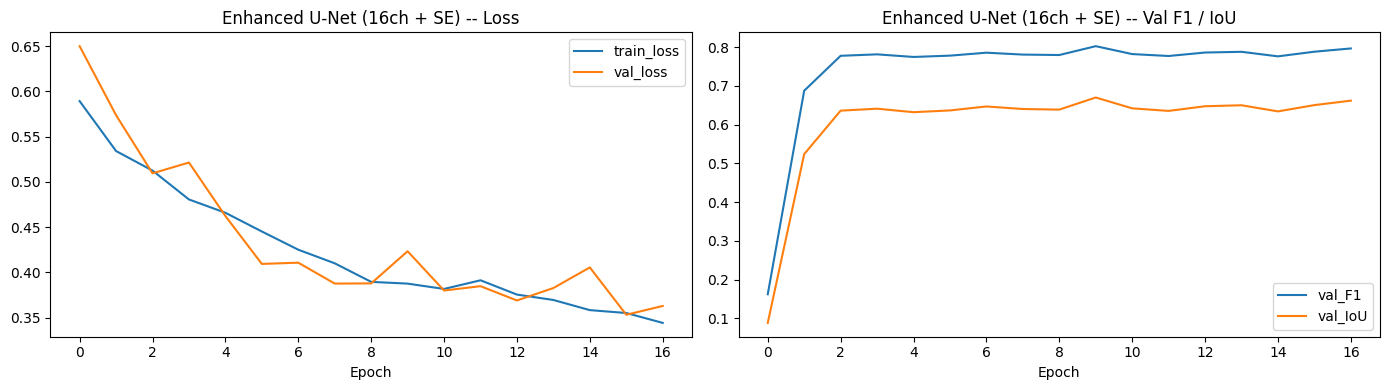

In [51]:
# --- Enhanced: 16 channels (12 + engineered indices), U-Net with SE blocks ---
train_loader_enh, val_loader_enh, test_loader_enh = make_loaders(use_engineered_features=True, batch_size=BATCH_SIZE)
enhanced_model = UNet(in_channels=16, use_se=True, base_ch=32)
enhanced_model, enhanced_history = train_model(
    enhanced_model, train_loader_enh, val_loader_enh, model_name='unet_enhanced', epochs=EPOCHS
)
plot_history(enhanced_history, 'Enhanced U-Net (16ch + SE)')


## 15. Test Set Evaluation

In [52]:
@torch.no_grad()
def evaluate_on_test(model, test_loader, model_name):
    model.eval()
    tp = fp = fn = tn = 0
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        btp, bfp, bfn, btn = compute_confusion(logits, yb)
        tp += btp; fp += bfp; fn += bfn; tn += btn
    m = metrics_from_confusion(tp, fp, fn, tn)
    print(f"\n{model_name} -- Test set results:")
    print(f"  IoU:       {m['iou']:.4f}")
    print(f"  Precision: {m['precision']:.4f}")
    print(f"  Recall:    {m['recall']:.4f}")
    print(f"  F1-score:  {m['f1']:.4f}")
    return m

baseline_test_metrics = evaluate_on_test(baseline_model, test_loader_base, 'Baseline U-Net (12ch)')
enhanced_test_metrics = evaluate_on_test(enhanced_model, test_loader_enh, 'Enhanced U-Net (16ch + SE)')

print("\n" + "=" * 60)
print(f"{'Metric':<12}{'Baseline (12ch)':<20}{'Enhanced (16ch+SE)':<20}")
print("=" * 60)
for key in ['iou', 'precision', 'recall', 'f1']:
    print(f"{key.upper():<12}{baseline_test_metrics[key]:<20.4f}{enhanced_test_metrics[key]:<20.4f}")



Baseline U-Net (12ch) -- Test set results:
  IoU:       0.6730
  Precision: 0.7750
  Recall:    0.8364
  F1-score:  0.8045

Enhanced U-Net (16ch + SE) -- Test set results:
  IoU:       0.6729
  Precision: 0.8245
  Recall:    0.7855
  F1-score:  0.8045

Metric      Baseline (12ch)     Enhanced (16ch+SE)  
IOU         0.6730              0.6729              
PRECISION   0.7750              0.8245              
RECALL      0.8364              0.7855              
F1          0.8045              0.8045              


## 16. Qualitative Predictions

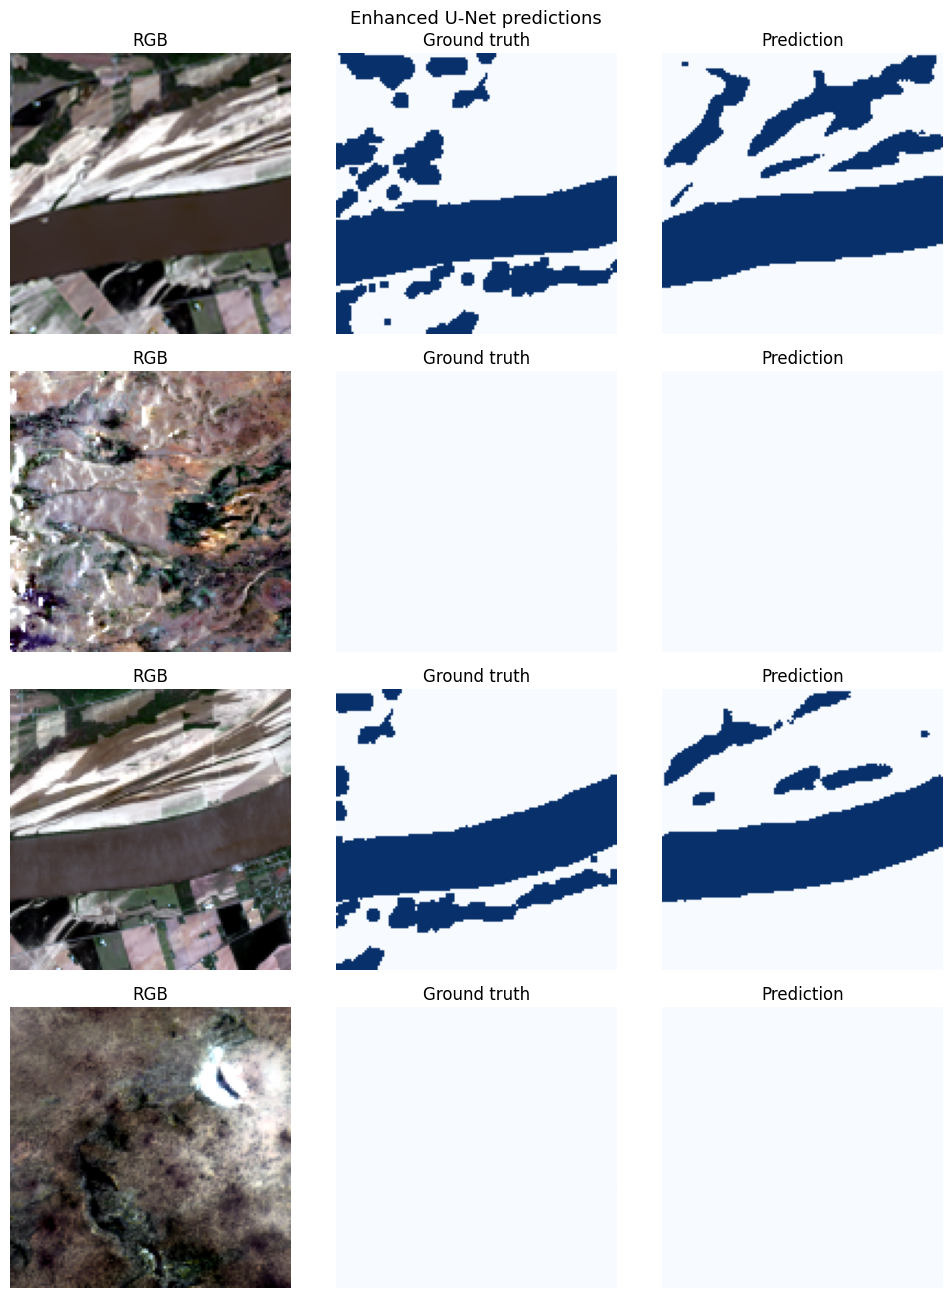

In [53]:
@torch.no_grad()
def show_predictions(model, stems, use_engineered_features, n=4, model_name=''):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(10, 3.3 * n))
    chosen = random.sample(stems, n)
    for row, stem in enumerate(chosen):
        raw_img = to_chw(tifffile.imread(os.path.join(IMAGES_DIR, stem + '.tif')))
        mask = (np.array(Image.open(os.path.join(LABELS_DIR, stem + '.png'))) > 0).astype(np.float32)

        norm_img = normalize_channels(raw_img)
        if use_engineered_features:
            img = np.concatenate([norm_img, compute_indices(raw_img)], axis=0)
        else:
            img = norm_img

        x = torch.from_numpy(img).float().unsqueeze(0).to(device)
        pred = (torch.sigmoid(model(x)) > 0.5).float().cpu().numpy()[0, 0]

        rgb = np.stack([stretch(raw_img[3]), stretch(raw_img[2]), stretch(raw_img[1])], axis=-1)
        axes[row, 0].imshow(rgb); axes[row, 0].set_title('RGB'); axes[row, 0].axis('off')
        axes[row, 1].imshow(mask, cmap='Blues'); axes[row, 1].set_title('Ground truth'); axes[row, 1].axis('off')
        axes[row, 2].imshow(pred, cmap='Blues'); axes[row, 2].set_title('Prediction'); axes[row, 2].axis('off')

    fig.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{model_name.replace(" ", "_")}_predictions.png', dpi=100, bbox_inches='tight')
    plt.show()

show_predictions(enhanced_model, test_stems, use_engineered_features=True, n=4, model_name='Enhanced U-Net predictions')


## 17. Save Models & Wrap Up

For your README/report, make sure to cover:
- Dataset structure, band layout, label distribution (Sections 1-5 above)
- Band research table + the ESA WorldCover / Water-occurrence leakage discussion (Section 4)
- Why dataset-wide per-channel normalization was used instead of per-image (Section 8)
- The engineered features and why each was chosen (Section 9)
- U-Net architecture summary + the SE-block enhancement (Section 11)
- Baseline vs. enhanced comparison table (Section 15) -- this is the evidence that you went
  beyond "just all 12 channels"
- A few qualitative prediction examples (Section 16)


In [54]:
os.makedirs('/kaggle/working/final_models', exist_ok=True)
torch.save(baseline_model.state_dict(), '/kaggle/working/final_models/unet_baseline_final.pt')
torch.save(enhanced_model.state_dict(), '/kaggle/working/final_models/unet_enhanced_final.pt')
with open('/kaggle/working/final_models/channel_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print("Saved final model weights and normalization stats to /kaggle/working/final_models/")
print("Copy this folder to your mounted Drive (or download it) before the Colab session ends.")


Saved final model weights and normalization stats to /kaggle/working/final_models/
Copy this folder to your mounted Drive (or download it) before the Colab session ends.


In [55]:
xb, yb = next(iter(train_loader_enh))
print(f"Batch shape: {tuple(xb.shape)}")
for i in range(xb.shape[1]):
    ch = xb[:, i]
    name = BAND_NAMES[i] if i < 12 else EXTRA_FEATURE_NAMES[i - 12]
    print(f"  ch{i:2d} {name:<22s}: min={ch.min():.4f} max={ch.max():.4f} mean={ch.mean():.4f} "
          f"NaN={torch.isnan(ch).sum().item()} Inf={torch.isinf(ch).sum().item()}")
print(f"\nMask: min={yb.min()}, max={yb.max()}, mean={yb.mean():.4f}, "
      f"NaN={torch.isnan(yb).sum().item()}")

Batch shape: (16, 16, 128, 128)
  ch 0 Coastal aerosol       : min=0.1288 max=0.5877 mean=0.2206 NaN=0 Inf=0
  ch 1 Blue                  : min=0.0543 max=0.5758 mean=0.1458 NaN=0 Inf=0
  ch 2 Green                 : min=0.0308 max=0.5295 mean=0.1178 NaN=0 Inf=0
  ch 3 Red                   : min=0.0424 max=0.5414 mean=0.1240 NaN=0 Inf=0
  ch 4 NIR                   : min=0.0200 max=0.4221 mean=0.1313 NaN=0 Inf=0
  ch 5 SWIR1                 : min=0.0073 max=0.3615 mean=0.1287 NaN=0 Inf=0
  ch 6 SWIR2                 : min=0.0054 max=0.3978 mean=0.0935 NaN=0 Inf=0
  ch 7 QA Band               : min=0.0000 max=1.0000 mean=0.2681 NaN=0 Inf=0
  ch 8 Merit DEM             : min=0.7031 max=0.7786 mean=0.7115 NaN=0 Inf=0
  ch 9 Copernicus DEM        : min=0.0005 max=0.2685 mean=0.0304 NaN=0 Inf=0
  ch10 ESA WorldCover        : min=0.0000 max=0.8889 mean=0.3117 NaN=0 Inf=0
  ch11 Water occurrence probability: min=0.0000 max=0.9009 mean=0.1159 NaN=0 Inf=0
  ch12 NDWI                  : min=0.0